# Setup

## Imports

In [1]:
import re
import random
import time
from collections import Counter
from dataclasses import dataclass
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torch.nn as nn
import torch.nn.functional as F


## Other Parameters

We set the seed to get reproducable results and use a GPU if one is available for faster training

In [4]:
def set_seed(seed: int = 42) -> None:
    """Set random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

In [5]:
if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    device = torch.device("cuda")
else:
    print("Using CPU")
    device = torch.device("cpu")
device

Using GPU: NVIDIA GeForce RTX 3060


device(type='cuda')

# Data Preprocessing

In [6]:
splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}

train_df = pd.read_json("hf://datasets/sh0416/ag_news/" + splits["train"], lines=True)
test_df = pd.read_json("hf://datasets/sh0416/ag_news/" + splits["test"], lines=True)


The following cell uses regular expressions to cut out html code for embedded images and links.

In [7]:
train_df['description'] = train_df['description'].apply(lambda x: re.sub("&lt.*?/.*?&gt;", "", x))
test_df['description'] = test_df['description'].apply(lambda x: re.sub("&lt.*?/.*?&gt;", "", x))



Since the data already came pre-split into train and test data, we use test_train_split on the training set to create a dev validation set. This is 10% of the training dataset. We are also combining the title and the description under one variable called "text" for ease of training.

In [8]:
train_df["text"] = train_df["title"] + " " + train_df["description"]
test_df["text"] = test_df["title"] + " " + test_df["description"]

target_names = ["World", "Sports", "Business", "Sci/Tech"]
X = train_df[["text"]]
y = train_df["label"]
y_test = test_df["label"]

X_train, X_dev, y_train, y_dev = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

Creates a dictionary to be used in tokenization and training, This is needed to create the vocabulary

In [9]:
train_ds_hf = [{"text": t, "label": l} for t, l in zip(X_train["text"], y_train)]
val_ds_hf = [{"text": t, "label": l} for t, l in zip(X_dev["text"], y_dev)]
test_ds_hf = [{"text": t, "label": l} for t, l in zip(test_df["text"], test_df["label"])]

# Tokenisation and Vocabulary

In [10]:
TOKEN_RE = re.compile(r"[A-Za-z0-9']+")

PAD = "<pad>"
UNK = "<unk>"

def tokenize(text: str):
    return TOKEN_RE.findall(text.lower())

def build_vocab(texts, min_freq: int = 2, max_size: int = 30000) -> dict:
    counter = Counter()
    for t in texts:
        counter.update(tokenize(t))
    vocab = {PAD: 0, UNK: 1}
    for word, freq in counter.most_common():
        if freq < min_freq:
            break
        if len(vocab) >= max_size:
            break
        vocab[word] = len(vocab)
    return vocab

vocab = build_vocab([d["text"] for d in train_ds_hf], min_freq=2, max_size=30000)
vocab_size = len(vocab)
PAD_IDX = vocab[PAD]
UNK_IDX = vocab[UNK]

def numericalize(tokens: list, vocab: dict) -> list:
    return [vocab.get(tok, UNK_IDX) for tok in tokens]

# Dataset and Collate

In [11]:
@dataclass
class Batch:
    x: torch.Tensor
    lengths: torch.Tensor
    y: torch.Tensor

class TextDataset(Dataset):
    def __init__(self, hf_ds: list, vocab: dict, max_len: int = 200) -> None:
        self.ds = hf_ds
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx: int):
        item = self.ds[idx]
        tokens = tokenize(item["text"])
        ids = numericalize(tokens, self.vocab)[:self.max_len]
        if len(ids) == 0:
            ids = [UNK_IDX]
        label = int(item["label"]) - 1
        return ids, label

def collate(batch: list) -> Batch:
    lengths = torch.tensor([len(x) for x, _ in batch], dtype=torch.long)
    max_len = int(lengths.max().item()) if len(batch) > 0 else 0
    x = torch.full((len(batch), max_len), PAD_IDX, dtype=torch.long)
    y = torch.tensor([y for _, y in batch], dtype=torch.long)
    for i, (ids, _) in enumerate(batch):
        x[i, :len(ids)] = torch.tensor(ids, dtype=torch.long)
    return Batch(x=x, lengths=lengths, y=y)

MAX_LEN = 200
BATCH_SIZE = 64

train_ds = TextDataset(train_ds_hf, vocab, max_len=MAX_LEN)
val_ds = TextDataset(val_ds_hf, vocab, max_len=MAX_LEN)
test_ds = TextDataset(test_ds_hf, vocab, max_len=MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

# Model training and performance

## LSTM initialisation

For the LSTM we use embed_dim = 64 and hidden_dim = 64 to balance model capacity and training time. We use num_layers = 2 to capture sequential patterns. The model is unidirectional by setting bidirectional = False to reduce parameters, and num_classes = 4 corresponding to AG News categories. We also have the dropout disabled.

In [12]:
class LSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int = 64,
        hidden_dim: int = 64,
        num_layers: int = 2,
        dropout: float = 0,
        pad_idx: int = PAD_IDX,
        num_classes: int = 4,
        bidirectional: bool = False,
    ):
        super().__init__()
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.emb_dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        rep_dim = hidden_dim * (2 if bidirectional else 1)
        self.rep_dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(rep_dim, num_classes)

    def forward(self, x, lengths):
        emb = self.emb_dropout(self.embedding(x))
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)
        if self.bidirectional:
            h_last = torch.cat([h_n[-2], h_n[-1]], dim=1)
        else:
            h_last = h_n[-1]
        rep = self.rep_dropout(h_last)
        return self.fc(rep)

## CNN initialisation

For the CNN we use embed_dim = 64 and num_filters = 64 to balance model complexity and computational efficiency. We use kernel_sizes = (3, 4, 5) to allow the network to capture n-gram features of varying lengths. We usenum_classes = 4 corresponding to AG News categories. We also have the dropout disabled.

In [13]:
class CNNTextClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int = 64,
        num_filters: int = 64,
        kernel_sizes: tuple = (3, 4, 5),
        dropout: float = 0,
        pad_idx: int = PAD_IDX,
        num_classes: int = 4,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.emb_dropout = nn.Dropout(dropout)
        self.convs = nn.ModuleList(
            [nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes]
        )
        self.rep_dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        emb = self.emb_dropout(self.embedding(x))
        emb_t = emb.transpose(1, 2)
        pooled = []
        for conv in self.convs:
            z = torch.relu(conv(emb_t))
            p = torch.max(z, dim=2).values
            pooled.append(p)
        rep = torch.cat(pooled, dim=1)
        rep = self.rep_dropout(rep)
        return self.fc(rep)

## Training

In [15]:
def evaluate(model: nn.Module, loader: DataLoader) -> dict:
    model.eval()
    all_y = []
    all_pred = []
    total_loss = 0.0
    n = 0
    loss_fn = nn.CrossEntropyLoss()
    with torch.no_grad():
        for batch in loader:
            x = batch.x.to(device)
            lengths = batch.lengths.to(device)
            y = batch.y.to(device)

            if isinstance(model, LSTMClassifier):
                logits = model(x, lengths)
            else:
                logits = model(x)
            loss = loss_fn(logits, y)

            pred = logits.argmax(dim=1)
            all_y.append(y.cpu().numpy())
            all_pred.append(pred.cpu().numpy())
            total_loss += loss.item() * y.size(0)
            n += y.size(0)

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_pred)
    return {
        "loss": total_loss / max(1, n),
        "acc": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, average="macro"),
        "y_true": y_true,
        "y_pred": y_pred,
    }


def fit(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    lr: float = 1e-3,
    max_epochs: int = 20,
    weight_decay: float = 0.0,
    clip_grad_norm: float | None = None,
    patience: int | None = 3,
) -> list:
    """
    Train the model, optionally with early stopping on validation loss.

    If clip_grad_norm is not None, gradients are clipped by global norm after backward.
    We log the pre clipping total gradient norm each epoch.
    """
    loss_fn = nn.CrossEntropyLoss()
    optim = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = None
    best_val = float("inf")
    bad_epochs = 0

    hist = []
    for epoch in range(1, max_epochs + 1):
        model.train()
        t0 = time.perf_counter()

        total_loss = 0.0
        n = 0
        correct = 0

        grad_norms = []

        for batch in train_loader:
            x = batch.x.to(device)
            lengths = batch.lengths.to(device)
            y = batch.y.to(device)

            optim.zero_grad(set_to_none=True)
            if isinstance(model, LSTMClassifier):
                logits = model(x, lengths)
            else:
                logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()

            # Measure global grad norm before clipping.
            total_norm_sq = 0.0
            for p in model.parameters():
                if p.grad is None:
                    continue
                param_norm = p.grad.data.norm(2).item()
                total_norm_sq += param_norm * param_norm
            total_norm = float(total_norm_sq ** 0.5)
            grad_norms.append(total_norm)

            if clip_grad_norm is not None:
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad_norm)

            optim.step()

            total_loss += loss.item() * y.size(0)
            n += y.size(0)
            correct += (logits.argmax(dim=1) == y).sum().item()

        train_loss = total_loss / max(1, n)
        train_acc = correct / max(1, n)
        val = evaluate(model, val_loader)
        dt = time.perf_counter() - t0

        record = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val["loss"],
            "val_acc": val["acc"],
            "val_f1": val["f1"],
            "time_s": dt,
            "grad_norm_mean": float(np.mean(grad_norms)) if len(grad_norms) else float("nan"),
            "grad_norm_p95": float(np.percentile(grad_norms, 95)) if len(grad_norms) else float("nan"),
            "grad_norm_max": float(np.max(grad_norms)) if len(grad_norms) else float("nan"),
        }
        hist.append(record)

        print(
            f"epoch {epoch:02d} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
            f"val loss {val['loss']:.4f} acc {val['acc']:.4f} f1 {val['f1']:.4f} | "
            f"grad norm mean {record['grad_norm_mean']:.2f} max {record['grad_norm_max']:.2f} | "
            f"time {dt:.1f}s"
        )

        if patience is not None:
            if val["loss"] < best_val - 1e-6:
                best_val = val["loss"]
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                bad_epochs = 0
            else:
                bad_epochs += 1
                if bad_epochs >= patience:
                    print("Early stopping triggered, restoring best parameters.")
                    if best_state is not None:
                        model.load_state_dict(best_state)
                    break

    if patience is not None and best_state is not None:
        model.load_state_dict(best_state)

    return hist


## Dev set performance

In [16]:
lstm_model = LSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=64,
    hidden_dim=64,
    num_layers=2,
    dropout=0,
    pad_idx=PAD_IDX,
    num_classes=4
).to(device)

cnn_model = CNNTextClassifier(
    vocab_size=vocab_size,
    embed_dim=64,
    num_filters=64,
    kernel_sizes=(3,4,5),
    dropout=0,
    pad_idx=PAD_IDX,
    num_classes=4
).to(device)

print("Training LSTM")
lstm_hist = fit(
    lstm_model,
    train_loader,
    val_loader,
    lr=1e-3,
    max_epochs=20,
    clip_grad_norm=5.0,
    patience=3
)

print("Training CNN")
cnn_hist = fit(
    cnn_model,
    train_loader,
    val_loader,
    lr=1e-3,
    max_epochs=20,
    clip_grad_norm=5.0,
    patience=3
)

Training LSTM
epoch 01 | train loss 0.5817 acc 0.7693 | val loss 0.3454 acc 0.8846 f1 0.8842 | grad norm mean 1.76 max 7.11 | time 17.6s
epoch 02 | train loss 0.3060 acc 0.8985 | val loss 0.3029 acc 0.9008 f1 0.9009 | grad norm mean 1.36 max 5.17 | time 17.5s
epoch 03 | train loss 0.2415 acc 0.9217 | val loss 0.2889 acc 0.9007 f1 0.9003 | grad norm mean 1.10 max 6.15 | time 13.0s
epoch 04 | train loss 0.2001 acc 0.9364 | val loss 0.2923 acc 0.9060 f1 0.9061 | grad norm mean 0.98 max 4.77 | time 13.0s
epoch 05 | train loss 0.1652 acc 0.9473 | val loss 0.2854 acc 0.9101 f1 0.9103 | grad norm mean 0.88 max 3.36 | time 13.0s
epoch 06 | train loss 0.1386 acc 0.9562 | val loss 0.2991 acc 0.9079 f1 0.9080 | grad norm mean 0.86 max 12.28 | time 12.8s
epoch 07 | train loss 0.1153 acc 0.9636 | val loss 0.3088 acc 0.9062 f1 0.9061 | grad norm mean 0.79 max 8.77 | time 12.9s
epoch 08 | train loss 0.0935 acc 0.9713 | val loss 0.3378 acc 0.9065 f1 0.9065 | grad norm mean 0.73 max 4.17 | time 13.1s
E

## Test set performace

In [17]:
lstm_test = evaluate(lstm_model, test_loader)
cnn_test = evaluate(cnn_model, test_loader)

print("LSTM test accuracy:", lstm_test["acc"])
print("CNN test accuracy:", cnn_test["acc"])

LSTM test accuracy: 0.9019736842105263
CNN test accuracy: 0.8932894736842105


Due to the small differences in accuracy between the LSTM and the CNN we decided to select the CNN model for the ablation study and error analysis. This decision is backed up by the efficiency in speed that the CNN model has over the LSTM model, where, on average, each epoch in the CNN takes around half the time an epoch in the LSTM model takes.

## Ablation Study

In our Ablation study we take the same CNN parameters as before and only change the dropout parameter to 0.3, We suspect this will improve it's accuracy and performance. With this parameter neurons have a 30% chance to not be used during a certain forward or backward pass. This forces it's neigbours to not rely on the output of this neuron and makes the model in general rely less on singular neurons. This should help with the generalizablity and accuracy of the model.

In [18]:
cnn_model_three_dropout = CNNTextClassifier(
    vocab_size=vocab_size,
    embed_dim=64,
    num_filters=64,
    kernel_sizes=(3,4,5),
    dropout=0.3,
    pad_idx=PAD_IDX,
    num_classes=4
).to(device)

print("Training CNN_dropout_0.3")
cnn_hist_three_dropout = fit(
    cnn_model_three_dropout,
    train_loader,
    val_loader,
    lr=1e-3,
    max_epochs=20,
    clip_grad_norm=5.0,
    patience=3
)

ablation_cnn_test = evaluate(cnn_model_three_dropout, test_loader)

print("CNN test accuracy:", ablation_cnn_test["acc"])

Training CNN_dropout_0.3
epoch 01 | train loss 0.7935 acc 0.6757 | val loss 0.4067 acc 0.8628 f1 0.8611 | grad norm mean 2.63 max 8.15 | time 9.5s
epoch 02 | train loss 0.4353 acc 0.8481 | val loss 0.3187 acc 0.8928 f1 0.8923 | grad norm mean 2.00 max 5.29 | time 9.4s
epoch 03 | train loss 0.3560 acc 0.8792 | val loss 0.2903 acc 0.9037 f1 0.9035 | grad norm mean 1.81 max 4.47 | time 9.5s
epoch 04 | train loss 0.3092 acc 0.8953 | val loss 0.2744 acc 0.9080 f1 0.9078 | grad norm mean 1.65 max 4.08 | time 9.6s
epoch 05 | train loss 0.2780 acc 0.9061 | val loss 0.2691 acc 0.9130 f1 0.9127 | grad norm mean 1.55 max 3.96 | time 9.5s
epoch 06 | train loss 0.2543 acc 0.9141 | val loss 0.2583 acc 0.9159 f1 0.9158 | grad norm mean 1.47 max 3.88 | time 9.4s
epoch 07 | train loss 0.2364 acc 0.9196 | val loss 0.2520 acc 0.9177 f1 0.9176 | grad norm mean 1.42 max 3.74 | time 9.5s
epoch 08 | train loss 0.2204 acc 0.9253 | val loss 0.2558 acc 0.9181 f1 0.9179 | grad norm mean 1.40 max 3.56 | time 9.4s

## Error Analysis

We print the confusion matrices for the original CNN and the tuned CNN (with a dropout rate of 30%). For the total errors and its analysis we will take the tuned CNN as this is the better performing version of the model.


CNN Classification Report
              precision    recall  f1-score   support

       World       0.92      0.88      0.90      1900
      Sports       0.95      0.96      0.95      1900
    Business       0.87      0.84      0.85      1900
    Sci/Tech       0.84      0.90      0.87      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600


CNN_Dropout_0.3 Classification Report
              precision    recall  f1-score   support

       World       0.93      0.91      0.92      1900
      Sports       0.96      0.98      0.97      1900
    Business       0.88      0.88      0.88      1900
    Sci/Tech       0.89      0.89      0.89      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



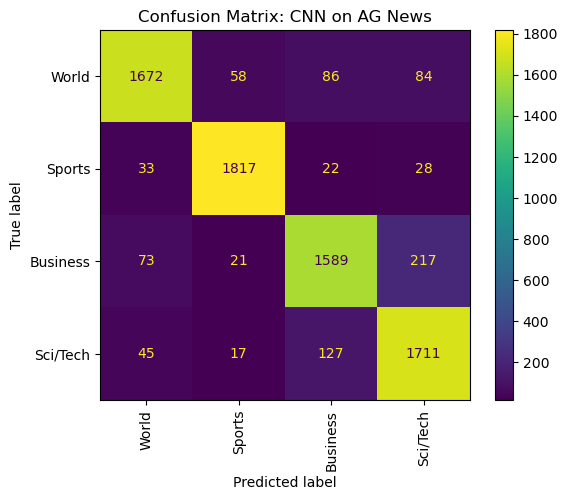

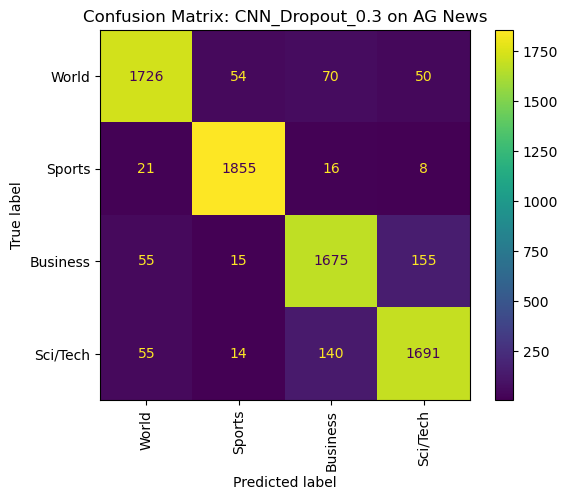

In [21]:
target_names = ["World", "Sports", "Business", "Sci/Tech"]

print("\nCNN Classification Report")
print(classification_report(cnn_test["y_true"], cnn_test["y_pred"], target_names=target_names))

print("\nCNN_Dropout_0.3 Classification Report")
print(classification_report(ablation_cnn_test["y_true"], ablation_cnn_test["y_pred"], target_names=target_names))

# CNN
cm_cnn = confusion_matrix(cnn_test["y_true"], cnn_test["y_pred"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=target_names)
disp.plot(xticks_rotation='vertical')
plt.title("Confusion Matrix: CNN on AG News")
plt.show()

# Ablation CNN - Dropout 0.3
cm_cnn_ablation = confusion_matrix(ablation_cnn_test["y_true"], ablation_cnn_test["y_pred"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn_ablation, display_labels=target_names)
disp.plot(xticks_rotation='vertical')
plt.title("Confusion Matrix: CNN_Dropout_0.3 on AG News")
plt.show()

In [22]:
texts = [item["text"] for item in test_ds_hf]

y_true = ablation_cnn_test["y_true"]
y_pred = ablation_cnn_test["y_pred"]

true_labels = [target_names[i] for i in y_true]
pred_labels = [target_names[i] for i in y_pred]

min_len = min(len(test_ds_hf), len(y_true), len(y_pred))
texts = [item["text"] for item in test_ds_hf[:min_len]]
y_true = y_true[:min_len]
y_pred = y_pred[:min_len]

true_labels = [target_names[i] for i in y_true]
pred_labels = [target_names[i] for i in y_pred]

df_predictions = pd.DataFrame({
    "text": texts,
    "true_label": true_labels,
    "pred_label": pred_labels
})

errors = df_predictions[df_predictions["true_label"] != df_predictions["pred_label"]]

print(f"Total Errors: {len(errors)}")
print("Displaying first 20 misclassifications:")

pd.set_option("display.max_colwidth", 150)
display(errors.head(20))

Total Errors: 653
Displaying first 20 misclassifications:


,text,true_label,pred_label
9,"Card fraud unit nets 36,000 cards In its first two years, the UK's dedicated card fraud unit, has recovered 36,000 stolen cards and 171 arrests - ...",Sci/Tech,Business
23,"Some People Not Eligible to Get in on Google IPO Google has billed its IPO as a way for everyday people to get in on the process, denying Wall Str...",Sci/Tech,Business
24,"Rivals Try to Turn Tables on Charles Schwab By MICHAEL LIEDTKE SAN FRANCISCO (AP) -- With its low prices and iconoclastic attitude, discount s...",Sci/Tech,Business
55,"Promoting a Shared Vision As Michael Kaleko kept running into people who were getting older and having more vision problems, he realized he could ...",Sci/Tech,Sports
79,Live: Olympics day four Richard Faulds and Stephen Parry are going for gold for Great Britain on day four in Athens.,World,Sports
83,"Intel to delay product aimed for high-definition TVs SAN FRANCISCO -- In the latest of a series of product delays, Intel Corp. has postponed the l...",Business,Sci/Tech
84,Venezuela vote keeps Chavez as president CARACAS -- Venezuelans voted resoundingly to keep firebrand populist Hugo Chavez as their president in a ...,World,Business
89,Consumers Would Pay In Phone Proposal A proposal backed by a coalition of telephone carriers would cut billions of dollars in fees owed by long-di...,Sci/Tech,Business
106,Stocks Climb on Drop in Consumer Prices NEW YORK - Stocks rose for a second straight session Tuesday as a drop in consumer prices allowed investor...,World,Business
107,"Iliadis, Tanimoto win judo golds Ilias Iliadis of Greece thrilled the home crowd Tuesday, beating Roman Gontyuk of Ukraine to win the gold medal i...",Sports,World
